In [ ]:
!pip install transformers -q
print("Done ✅")

Done ✅


In [ ]:
import torch
import numpy as np
import cv2
import json
import os
import matplotlib.pyplot as plt
from PIL import Image
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

processor = CLIPSegProcessor.from_pretrained("CIDAS/clipseg-rd64-refined")
model     = CLIPSegForImageSegmentation.from_pretrained("CIDAS/clipseg-rd64-refined")

# Freeze encoders, only decoder trains
for name, param in model.named_parameters():
    if "decoder" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

model.to(DEVICE)
print("CLIPSeg loaded ✅")
print("Encoders frozen, decoder trainable ✅")

Device: cuda



Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).


preprocessor_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/603M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

CLIPSegForImageSegmentation LOAD REPORT from: CIDAS/clipseg-rd64-refined
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
clip.vision_model.embeddings.position_ids | UNEXPECTED |  | 
clip.text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIPSeg loaded ✅
Encoders frozen, decoder trainable ✅


In [ ]:
from PIL import ImageDraw

def annotation_to_mask(annotation, height, width):
    mask = np.zeros((height, width), dtype=np.uint8)
    if annotation["segmentation"]:
        for polygon in annotation["segmentation"]:
            pts = np.array([[polygon[i], polygon[i+1]]
                           for i in range(0, len(polygon), 2)], dtype=np.int32)
            cv2.fillPoly(mask, [pts], 255)
    else:
        x, y, w, h = [int(v) for v in annotation["bbox"]]
        mask[y:y+h, x:x+w] = 255
    return mask

def compute_metrics(pred_mask, gt_mask):
    pred = pred_mask > 127
    gt   = gt_mask   > 127
    intersection = np.logical_and(pred, gt).sum()
    union        = np.logical_or(pred, gt).sum()
    iou  = intersection / (union + 1e-6)
    dice = 2 * intersection / (pred.sum() + gt.sum() + 1e-6)
    return iou, dice

print("Functions ready ✅")

Functions ready ✅


In [ ]:
# Load annotations
with open("cracks-1/valid/_annotations.coco.json") as f:
    cracks_data = json.load(f)
with open("Drywall-Join-Detect-1/valid/_annotations.coco.json") as f:
    drywall_data = json.load(f)

dataset = []

# Cracks → polygon masks
for img_info in cracks_data["images"]:
    img_path = f"cracks-1/valid/{img_info['file_name']}"
    if not os.path.exists(img_path):
        continue
    anns = [a for a in cracks_data["annotations"] if a["image_id"] == img_info["id"]]
    if not anns:
        continue
    mask = np.zeros((img_info["height"], img_info["width"]), dtype=np.uint8)
    for ann in anns:
        mask = np.maximum(mask, annotation_to_mask(ann, img_info["height"], img_info["width"]))
    dataset.append({"image_path": img_path, "mask": mask, "prompt": "segment crack"})

# Drywall → bbox masks
for img_info in drywall_data["images"]:
    img_path = f"Drywall-Join-Detect-1/valid/{img_info['file_name']}"
    if not os.path.exists(img_path):
        continue
    anns = [a for a in drywall_data["annotations"] if a["image_id"] == img_info["id"]]
    if not anns:
        continue
    mask = np.zeros((img_info["height"], img_info["width"]), dtype=np.uint8)
    for ann in anns:
        mask = np.maximum(mask, annotation_to_mask(ann, img_info["height"], img_info["width"]))
    dataset.append({"image_path": img_path, "mask": mask, "prompt": "segment drywall joint"})

print(f"Total samples: {len(dataset)}")

Total samples: 403


In [ ]:
from torch.optim import Adam
import torch.nn.functional as F

optimizer = Adam([p for p in model.parameters() if p.requires_grad], lr=0.0001)

model.train()
EPOCHS = 3

for epoch in range(EPOCHS):
    total_loss = 0
    for idx, sample in enumerate(dataset):

        image   = Image.open(sample["image_path"]).convert("RGB")
        mask    = sample["mask"]
        prompt  = sample["prompt"]

        # Resize mask to 352x352 (CLIPSeg output size)
        mask_resized = cv2.resize(mask, (352, 352)) / 255.0
        mask_tensor  = torch.tensor(mask_resized, dtype=torch.float32).to(DEVICE)

        # Prepare inputs
        inputs = processor(
            text=[prompt],
            images=[image],
            return_tensors="pt",
            padding=True
        )
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

        # Forward pass
        outputs = model(**inputs)
        logits  = outputs.logits.squeeze()

        # Loss
        loss = F.binary_cross_entropy_with_logits(logits, mask_tensor)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if (idx + 1) % 50 == 0:
            print(f"Epoch {epoch+1}/3 | Sample {idx+1}/{len(dataset)} | Loss: {loss.item():.4f}")

    print(f"\n✅ Epoch {epoch+1} complete | Avg Loss: {total_loss/len(dataset):.4f}\n")

print("Training complete ✅")

Epoch 1/3 | Sample 50/403 | Loss: 0.1291
Epoch 1/3 | Sample 100/403 | Loss: 0.0349
Epoch 1/3 | Sample 150/403 | Loss: 0.0603
Epoch 1/3 | Sample 200/403 | Loss: 0.0778
Epoch 1/3 | Sample 250/403 | Loss: 0.3027
Epoch 1/3 | Sample 300/403 | Loss: 0.2045
Epoch 1/3 | Sample 350/403 | Loss: 0.4111
Epoch 1/3 | Sample 400/403 | Loss: 0.3168

✅ Epoch 1 complete | Avg Loss: 0.2214

Epoch 2/3 | Sample 50/403 | Loss: 0.0970
Epoch 2/3 | Sample 100/403 | Loss: 0.0369
Epoch 2/3 | Sample 150/403 | Loss: 0.0593
Epoch 2/3 | Sample 200/403 | Loss: 0.0791
Epoch 2/3 | Sample 250/403 | Loss: 0.1874
Epoch 2/3 | Sample 300/403 | Loss: 0.1753
Epoch 2/3 | Sample 350/403 | Loss: 0.2861
Epoch 2/3 | Sample 400/403 | Loss: 0.2809

✅ Epoch 2 complete | Avg Loss: 0.1841

Epoch 3/3 | Sample 50/403 | Loss: 0.0838
Epoch 3/3 | Sample 100/403 | Loss: 0.0384
Epoch 3/3 | Sample 150/403 | Loss: 0.0573
Epoch 3/3 | Sample 200/403 | Loss: 0.0780
Epoch 3/3 | Sample 250/403 | Loss: 0.1682
Epoch 3/3 | Sample 300/403 | Loss: 0.1672

In [ ]:
model.eval()

def predict(image_path, prompt):
    image  = Image.open(image_path).convert("RGB")
    inputs = processor(text=[prompt], images=[image], return_tensors="pt", padding=True)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    logits = outputs.logits.squeeze()
    pred   = torch.sigmoid(logits).cpu().numpy()
    pred   = (pred > 0.5).astype(np.uint8) * 255
    pred   = cv2.resize(pred, (640, 640))
    return pred

# Evaluate on cracks test
with open("cracks-1/test/_annotations.coco.json") as f:
    cracks_test = json.load(f)

all_iou, all_dice = [], []
for img_info in cracks_test["images"]:
    img_path = f"cracks-1/test/{img_info['file_name']}"
    if not os.path.exists(img_path): continue
    anns    = [a for a in cracks_test["annotations"] if a["image_id"] == img_info["id"]]
    gt_mask = np.zeros((img_info["height"], img_info["width"]), dtype=np.uint8)
    for ann in anns:
        gt_mask = np.maximum(gt_mask, annotation_to_mask(ann, img_info["height"], img_info["width"]))
    pred_mask     = predict(img_path, "segment crack")
    iou, dice     = compute_metrics(pred_mask, gt_mask)
    all_iou.append(iou)
    all_dice.append(dice)
    print(f"  IoU: {iou:.4f} Dice: {dice:.4f}")

print(f"\nCracks mIoU:  {np.mean(all_iou):.4f}")
print(f"Cracks mDice: {np.mean(all_dice):.4f}")

  IoU: 0.4064 Dice: 0.5779
  IoU: 0.5867 Dice: 0.7395
  IoU: 0.5225 Dice: 0.6864
  IoU: 0.2044 Dice: 0.3394

Cracks mIoU:  0.4300
Cracks mDice: 0.5858


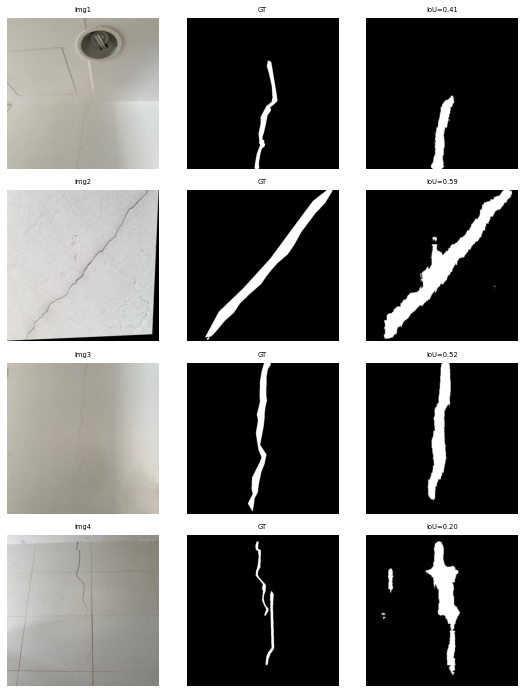

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(8, 10), dpi=70)

for i, img_info in enumerate(cracks_test["images"]):
    img_path  = f"cracks-1/test/{img_info['file_name']}"
    image_rgb = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    anns      = [a for a in cracks_test["annotations"] if a["image_id"] == img_info["id"]]
    gt_mask   = np.zeros((640, 640), dtype=np.uint8)
    for ann in anns:
        gt_mask = np.maximum(gt_mask, annotation_to_mask(ann, 640, 640))
    pred_mask     = predict(img_path, "segment crack")
    iou, _        = compute_metrics(pred_mask, gt_mask)
    axes[i][0].imshow(image_rgb);             axes[i][0].set_title(f"Img{i+1}",fontsize=7);    axes[i][0].axis("off")
    axes[i][1].imshow(gt_mask, cmap="gray");  axes[i][1].set_title("GT",fontsize=7);           axes[i][1].axis("off")
    axes[i][2].imshow(pred_mask, cmap="gray");axes[i][2].set_title(f"IoU={iou:.2f}",fontsize=7);axes[i][2].axis("off")

plt.tight_layout()
plt.show()

IndexError: index 4 is out of bounds for axis 0 with size 4

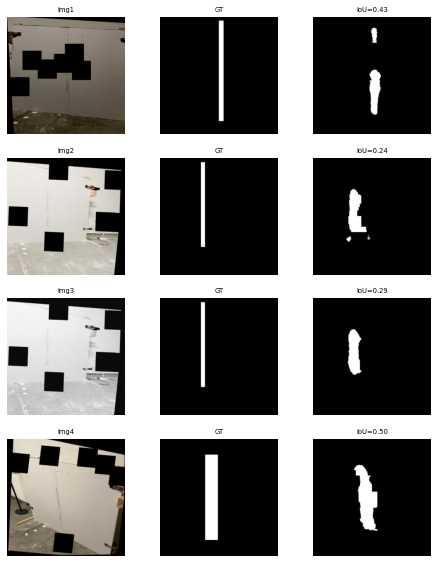

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(8, 10), dpi=70)

for i, img_info in enumerate(drywall_data["images"]):

    img_path = f"Drywall-Join-Detect-1/valid/{img_info['file_name']}"

    image_rgb = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

    anns = [a for a in drywall_data["annotations"] if a["image_id"] == img_info["id"]]

    gt_mask = np.zeros((640, 640), dtype=np.uint8)

    for ann in anns:

        gt_mask = np.maximum(
            gt_mask,
            annotation_to_mask(ann, 640, 640)
        )

    pred_mask = predict(img_path, "segment drywall joint")

    iou, _ = compute_metrics(pred_mask, gt_mask)

    axes[i][0].imshow(image_rgb)
    axes[i][0].set_title(f"Img{i+1}", fontsize=7)
    axes[i][0].axis("off")

    axes[i][1].imshow(gt_mask, cmap="gray")
    axes[i][1].set_title("GT", fontsize=7)
    axes[i][1].axis("off")

    axes[i][2].imshow(pred_mask, cmap="gray")
    axes[i][2].set_title(f"IoU={iou:.2f}", fontsize=7)
    axes[i][2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
ious = []

for img_info in drywall_data["images"]:

    img_path = f"Drywall-Join-Detect-1/valid/{img_info['file_name']}"

    anns = [a for a in drywall_data["annotations"] if a["image_id"] == img_info["id"]]

    gt_mask = np.zeros((640, 640), dtype=np.uint8)

    for ann in anns:
        gt_mask = np.maximum(
            gt_mask,
            annotation_to_mask(ann, 640, 640)
        )

    pred_mask = predict(img_path, "segment drywall joint")

    iou, _ = compute_metrics(pred_mask, gt_mask)

    ious.append(iou)

print("Average Drywall IoU:", sum(ious)/len(ious))

Average Drywall IoU: 0.49853345194894894


In [ ]:
import numpy as np
import cv2

# metric function
def compute_all_metrics(pred_mask, gt_mask):

    pred = (pred_mask > 0.5).astype(np.uint8)
    gt   = (gt_mask > 0).astype(np.uint8)

    intersection = np.logical_and(pred, gt).sum()
    union        = np.logical_or(pred, gt).sum()

    iou = intersection / union if union != 0 else 0

    dice = (2 * intersection) / (pred.sum() + gt.sum()) if (pred.sum() + gt.sum()) != 0 else 0

    accuracy = (pred == gt).sum() / pred.size

    return iou, dice, accuracy

In [ ]:
crack_ious = []
crack_dices = []
crack_accs = []

for img_info in cracks_data["images"]:

    img_path = f"cracks-1/valid/{img_info['file_name']}"

    anns = [a for a in cracks_data["annotations"] if a["image_id"] == img_info["id"]]

    gt_mask = np.zeros((640, 640), dtype=np.uint8)

    for ann in anns:

        gt_mask = np.maximum(
            gt_mask,
            annotation_to_mask(ann, 640, 640)
        )

    pred_mask = predict(img_path, "segment crack")

    iou, dice, acc = compute_all_metrics(pred_mask, gt_mask)

    crack_ious.append(iou)
    crack_dices.append(dice)
    crack_accs.append(acc)


print("CRACK RESULTS")
print("Mean IoU:", np.mean(crack_ious))
print("Mean Dice:", np.mean(crack_dices))
print("Mean Accuracy:", np.mean(crack_accs))

CRACK RESULTS
Mean IoU: 0.41693105950567066
Mean Dice: 0.5629058299898972
Mean Accuracy: 0.9417010164023631


In [ ]:
drywall_ious = []
drywall_dices = []
drywall_accs = []

for img_info in drywall_data["images"]:

    img_path = f"Drywall-Join-Detect-1/valid/{img_info['file_name']}"

    anns = [a for a in drywall_data["annotations"] if a["image_id"] == img_info["id"]]

    gt_mask = np.zeros((640, 640), dtype=np.uint8)

    for ann in anns:

        gt_mask = np.maximum(
            gt_mask,
            annotation_to_mask(ann, 640, 640)
        )

    pred_mask = predict(img_path, "segment drywall joint")

    iou, dice, acc = compute_all_metrics(pred_mask, gt_mask)

    drywall_ious.append(iou)
    drywall_dices.append(dice)
    drywall_accs.append(acc)


print("\nDRYWALL RESULTS")
print("Mean IoU:", np.mean(drywall_ious))
print("Mean Dice:", np.mean(drywall_dices))
print("Mean Accuracy:", np.mean(drywall_accs))


DRYWALL RESULTS
Mean IoU: 0.502859230235467
Mean Dice: 0.6553227467432539
Mean Accuracy: 0.9094214592357673


In [ ]:
print("\nFINAL SUMMARY")

print("\nCracks:")
print("IoU:", np.mean(crack_ious))
print("Dice:", np.mean(crack_dices))
print("Accuracy:", np.mean(crack_accs))

print("\nDrywall:")
print("IoU:", np.mean(drywall_ious))
print("Dice:", np.mean(drywall_dices))
print("Accuracy:", np.mean(drywall_accs))


FINAL SUMMARY

Cracks:
IoU: 0.41693105950567066
Dice: 0.5629058299898972
Accuracy: 0.9417010164023631

Drywall:
IoU: 0.502859230235467
Dice: 0.6553227467432539
Accuracy: 0.9094214592357673


In [ ]:
import os
import matplotlib.pyplot as plt
import cv2
import numpy as np

os.makedirs("results/cracks", exist_ok=True)
os.makedirs("results/drywall", exist_ok=True)


def save_samples(dataset_data, dataset_name, prompt, folder):

    for i, img_info in enumerate(dataset_data["images"][:6]):

        img_path = f"{folder}/{img_info['file_name']}"

        image_rgb = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

        anns = [a for a in dataset_data["annotations"] if a["image_id"] == img_info["id"]]

        gt_mask = np.zeros((640, 640), dtype=np.uint8)

        for ann in anns:
            gt_mask = np.maximum(
                gt_mask,
                annotation_to_mask(ann, 640, 640)
            )

        pred_mask = predict(img_path, prompt)

        fig, axes = plt.subplots(1, 3, figsize=(9,3))

        axes[0].imshow(image_rgb)
        axes[0].set_title("Image")
        axes[0].axis("off")

        axes[1].imshow(gt_mask, cmap="gray")
        axes[1].set_title("Ground Truth")
        axes[1].axis("off")

        axes[2].imshow(pred_mask, cmap="gray")
        axes[2].set_title("Prediction")
        axes[2].axis("off")

        plt.tight_layout()

        save_path = f"results/{dataset_name}/sample_{i+1}.png"

        plt.savefig(save_path, dpi=300, bbox_inches="tight")

        plt.close()

        print("Saved:", save_path)



# Run for cracks

save_samples(
    cracks_data,
    "cracks",
    "segment crack",
    "cracks-1/valid"
)


# Run for drywall

save_samples(
    drywall_data,
    "drywall",
    "segment drywall joint",
    "Drywall-Join-Detect-1/valid"
)

Saved: results/cracks/sample_1.png
Saved: results/cracks/sample_2.png
Saved: results/cracks/sample_3.png
Saved: results/cracks/sample_4.png
Saved: results/cracks/sample_5.png
Saved: results/cracks/sample_6.png
Saved: results/drywall/sample_1.png
Saved: results/drywall/sample_2.png
Saved: results/drywall/sample_3.png
Saved: results/drywall/sample_4.png
Saved: results/drywall/sample_5.png
Saved: results/drywall/sample_6.png


In [ ]:
import nbformat

nb = nbformat.read("Prompted_Segmentation.ipynb", as_version=4)

if "widgets" in nb["metadata"]:
    del nb["metadata"]["widgets"]

nbformat.write(nb, "Prompted_Segmentation.ipynb")

FileNotFoundError: [Errno 2] No such file or directory: 'Prompted_Segmentation.ipynb'

In [ ]:
import os
print(os.listdir())

['.config', 'sam_vit_b_01ec64.pth', 'cracks-1', 'results', 'Drywall-Join-Detect-1', 'crack_results.png', 'sample_data']
